In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score

from sklearn.model_selection import train_test_split

# Get data

In [2]:
origin_2024_Q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/orig_2024Q1.txt",sep="|",header=None)
perform_2024_q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/perf_2024Q1.txt",sep="|",header=None)

/var/folders/t2/_pywhmm106s1vjr8m0jr12hm0000gn/T/ipykernel_29390/2225058536.py:2: DtypeWarning: Columns (0: 3, 1: 7, 2: 23, 3: 24, 4: 28) have mixed types. Specify dtype option on import or set low_memory=False.
  perform_2024_q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/perf_2024Q1.txt",sep="|",header=None)


In [3]:
origination_columns = [
    "classic_fico",
    "first_payment_date",
    "first_time_homebuyer_indicator",
    "maturity_date",
    "msa_or_metropolitan_division",
    "mi_percentage",
    "number_of_units",
    "occupancy_status",
    "original_cltv",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "channel",
    "prepayment_penalty_indicator",
    "amortization_type",
    "property_state",
    "property_type",
    "postal_code",
    "loan_identifier",
    "loan_purpose",
    "original_loan_term",
    "number_of_borrowers",
    "seller_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "special_eligibility_program",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator",
    "vantagescore_4_0"
]
performance_columns = [
    "loan_identifier",
    "period",
    "current_actual_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "underwriting_defect_and_major_servicing_defect_settlement_date",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_non_interest_bearing_upb",
    "due_date_of_last_paid_installment",
    "mi_recoveries",
    "net_sales_proceeds",
    "non_mi_recoveries",
    "total_expenses",
    "legal_costs",
    "maintenance_and_preservation_costs",
    "taxes_and_insurance",
    "miscellaneous_expenses",
    "actual_loss",
    "cumulative_modification_costs",
    "interest_rate_step_indicator",
    "payment_deferral_flag",
    "estimated_ltv",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_plan",
    "current_period_modification_costs",
    "current_interest_bearing_upb",
    "mortgage_insurance_cancellation_indicator",
    "servicer_name",
    "bankruptcy_cramdown_costs"
]

assert len(performance_columns) == 35

origin_2024_Q1_df.columns=origination_columns
perform_2024_q1_df.columns=performance_columns




# Preliminary

## Target table creation

In [4]:
origin_2024_Q1 = origin_2024_Q1_df.copy()
perform_2024_q1 = perform_2024_q1_df.copy()

In [5]:
assert origin_2024_Q1["loan_identifier"].is_unique

performance_with_age = perform_2024_q1.merge(
    origin_2024_Q1[
        ["loan_identifier", "first_payment_date"]
    ],
    on="loan_identifier",
    how="left",
    validate="many_to_one"
)

performance_with_age["first_payment_date_parsed"] = pd.to_datetime(
    performance_with_age["first_payment_date"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["period_parsed"] = pd.to_datetime(
    performance_with_age["period"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["original_loan_age"] = (
    (
        performance_with_age["period_parsed"].dt.year
        - performance_with_age["first_payment_date_parsed"].dt.year
    ) * 12
    +
    (
        performance_with_age["period_parsed"].dt.month
        - performance_with_age["first_payment_date_parsed"].dt.month
    )
    + 1
)

target_df = (
    performance_with_age.loc[
        performance_with_age["original_loan_age"].eq(20),
        [
            "loan_identifier",
            "current_loan_delinquency_status"
        ]
    ]
    .rename(
        columns={
            "current_loan_delinquency_status":
                "status_at_month_20"
        }
    )
    .reset_index(drop=True)
)

status_column = "status_at_month_20"

target_df[status_column] = (
    target_df[status_column]
    .astype("string")
    .str.strip()
    .str.upper()
)

numeric_mask = target_df[status_column].str.fullmatch(
    r"\d+"
)

target_df.loc[numeric_mask, status_column] = (
    target_df.loc[numeric_mask, status_column]
    .str.zfill(2)
)

status_numeric = pd.to_numeric(
    target_df[status_column],
    errors="coerce"
)

target_df["target_90plus"] = (
    status_numeric.ge(3)
    | target_df[status_column].eq("RA")
).astype("Int8")
unavailable_status = (
    target_df[status_column].isna()
    | target_df[status_column].eq("XX")
)

target_df.loc[
    unavailable_status,
    "target_90plus"
] = pd.NA

pd.crosstab(
    target_df[status_column],
    target_df["target_90plus"],
    dropna=False
)

target_df = target_df[
    ["loan_identifier", "target_90plus"]
].copy()

model_df = origin_2024_Q1.merge(
    target_df,
    on="loan_identifier",
    how="inner",
    validate="one_to_one"
)


## Data Cleaning

In [6]:
number_of_borrowers_map={
    3:2,
    4:2,
    5:2,
    6:2,
    7:2,
    8:2,
    9:2,
    10:2
}
evaluation_method_map={
    1:" appraisal waiver (ACE)",
    2:"appraisal",
    3:"other",
    4:"ACE_PDR"
}

In [7]:
model_df["classic_fico"] = model_df["classic_fico"].replace(to_replace=9999 , value=np.nan)
model_df["first_time_homebuyer_indicator"] = model_df["first_time_homebuyer_indicator"].replace(to_replace=9 , value=np.nan)
model_df["first_time_homebuyer_indicator"] = (model_df["first_time_homebuyer_indicator"] == "Y").astype(int)
model_df["mi_percentage"] = model_df["mi_percentage"].replace(to_replace=999 , value=np.nan)
model_df["number_of_units"] = model_df["number_of_units"].replace(to_replace=99 , value=np.nan)
model_df["occupancy_status"] = model_df["occupancy_status"].replace(to_replace=9 , value=np.nan)
model_df["original_cltv"] = model_df["original_cltv"].replace(to_replace=999 , value=np.nan)
model_df["original_dti"] = model_df["original_dti"].replace(to_replace=999 , value=np.nan)
model_df["original_ltv"] = model_df["original_ltv"].replace(to_replace=999 , value=np.nan)
model_df["channel"] = model_df["channel"].replace(to_replace=9 , value=np.nan)
model_df["prepayment_penalty_indicator"] = (model_df["prepayment_penalty_indicator"] == "Y").astype(int)
model_df["property_type"] = model_df["property_type"].replace(to_replace=99 , value=np.nan)
model_df["postal_code"] = model_df["postal_code"].replace(to_replace=000 , value=np.nan)
model_df["loan_purpose"] = model_df["loan_purpose"].replace(to_replace=9 , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(to_replace=99 , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(number_of_borrowers_map)
model_df["super_conforming_flag"] = (model_df["super_conforming_flag"] == "Y").astype(int)
model_df["special_eligibility_program"] = model_df["special_eligibility_program"].fillna("NONE_OR_NA")
model_df["property_valuation_method"] = model_df["property_valuation_method"].replace(to_replace=7 , value=np.nan)
model_df["property_valuation_method"] = model_df["property_valuation_method"].replace(evaluation_method_map)
first_payment_date= pd.to_datetime(
    model_df["first_payment_date"].astype("string"),
    format = "%Y%m",
    errors="coerce"
)
model_df["first_payment_month"]=first_payment_date.dt.month
maturity_date = pd.to_datetime(
    model_df["maturity_date"].astype("string"),
    format="%Y%m",
    errors="coerce"
)
model_df["effective_loan_duration"]= ((maturity_date.dt.year - first_payment_date.dt.year)*12+(maturity_date.dt.month-first_payment_date.dt.month))

del model_df["loan_identifier"]
del model_df["pre_harp_loan_sequence_number"]
del model_df["harp_indicator"]
del model_df["interest_only_indicator"]
del model_df["vantagescore_4_0"]
del model_df["first_payment_date"]
del model_df["maturity_date"]



In [8]:
model_df

,classic_fico,first_time_homebuyer_indicator,msa_or_metropolitan_division,mi_percentage,number_of_units,occupancy_status,original_cltv,original_dti,original_upb,original_ltv,...,loan_purpose,original_loan_term,number_of_borrowers,seller_name,super_conforming_flag,special_eligibility_program,property_valuation_method,target_90plus,first_payment_month,effective_loan_duration
0,747.0,0,NaN,0,1,P,67,26.0,82000,67,...,P,360,1,OTHER,0,NONE_OR_NA,appraisal,0,3,359
1,710.0,0,NaN,0,1,P,55,36.0,295000,55,...,C,360,1,OTHER,0,NONE_OR_NA,appraisal,0,5,359
2,659.0,0,NaN,0,1,P,68,32.0,305000,68,...,P,360,2,OTHER,0,NONE_OR_NA,appraisal,0,3,359
3,784.0,0,46540.0,0,1,P,76,50.0,125000,76,...,C,360,1,OTHER,0,NONE_OR_NA,appraisal,0,3,359
4,775.0,0,46540.0,0,2,I,70,15.0,154000,70,...,C,360,2,OTHER,0,NONE_OR_NA,appraisal,0,3,359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182997,764.0,0,26420.0,0,1,I,80,42.0,112000,80,...,P,180,2,OTHER,0,NONE_OR_NA,appraisal,0,5,179
182998,742.0,0,26420.0,0,1,P,80,34.0,436000,80,...,P,360,1,OTHER,0,NONE_OR_NA,appraisal,0,4,359
182999,698.0,1,35614.0,35,1,P,102,50.0,451000,97,...,P,360,2,OTHER,0,F,appraisal,0,4,359
183000,728.0,1,15804.0,30,1,P,100,24.0,219000,95,...,P,360,2,OTHER,0,F,appraisal,0,3,359


## Column division 

In [9]:
columns=[
    'classic_fico', 'first_time_homebuyer_indicator',
       'msa_or_metropolitan_division', 'mi_percentage', 'number_of_units',
       'occupancy_status', 'original_cltv', 'original_dti', 'original_upb',
       'original_ltv', 'original_interest_rate', 'channel',
       'prepayment_penalty_indicator', 'amortization_type', 'property_state',
       'property_type', 'postal_code', 'loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'super_conforming_flag',
       'special_eligibility_program', 'property_valuation_method',
       'first_payment_month', "effective_loan_duration"
]
all_columns = columns + ["target_90plus"]


numerical_columns =['classic_fico','mi_percentage','original_cltv', 'original_dti', 'original_upb',
       'original_ltv', 'original_interest_rate',]

categorical_columns=['first_time_homebuyer_indicator','msa_or_metropolitan_division','number_of_units','occupancy_status','channel',
       'prepayment_penalty_indicator', 'amortization_type', 'property_state',
       'property_type','postal_code','loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'super_conforming_flag','special_eligibility_program', 'property_valuation_method',
               'first_payment_month', "effective_loan_duration"]


In [10]:
model_df[categorical_columns]=model_df[categorical_columns].astype("string")
model_df[numerical_columns]=model_df[numerical_columns].astype("float64")


# EDA

In [11]:
model_df_eda = model_df.copy()
origin_2024_Q1_eda= origin_2024_Q1.copy()

## Basic exploration

In [12]:
n_loans = origin_2024_Q1.shape[0]
print(f"Number of original loans : {n_loans}")
print(f"Number of lians with 20 month target : {model_df.shape[0]}")
print(f"Number of excluded loans : {n_loans-model_df.shape[0]} , that is {round(((n_loans-model_df.shape[0])/n_loans)*100,3)} %")

Number of original loans : 215009
Number of lians with 20 month target : 183002
Number of excluded loans : 32007 , that is 14.886 %


In [13]:
defective_df =  model_df.target_90plus.value_counts(dropna=False)
global_defective = model_df.target_90plus.mean() 

print(f"Non defective loans in 20 months time with a defectivness of 90+ days : {defective_df.loc[0]} \nDefective loans in 20 months time with a defectivness of 90+ days : {defective_df.iloc[1]}")
print(f"\n\nGlobal defective rate : {round(global_defective,5)} %")
print("\nThe data id highly unbalanced , this have to be taken into consideration for evaluation")

Non defective loans in 20 months time with a defectivness of 90+ days : 181722 
Defective loans in 20 months time with a defectivness of 90+ days : 1280


Global defective rate : 0.00699 %

The data id highly unbalanced , this have to be taken into consideration for evaluation


## Analize target coverage

In [14]:
origin_2024_Q1_eda["has_month_20_target"]=(
    origin_2024_Q1_eda["loan_identifier"].isin(target_df["loan_identifier"]).astype("int8")
)

In [15]:
# What happend to those not chosen loans : evaluating bias

excluded_loans_identifier = origin_2024_Q1_eda.loc[origin_2024_Q1_eda["has_month_20_target"].eq(0),"loan_identifier"]
performance_excluded_loans = perform_2024_q1.loc[perform_2024_q1["loan_identifier"].isin(excluded_loans_identifier)].copy()

performance_excluded_loans = performance_excluded_loans.sort_values(["loan_identifier","period"]).groupby("loan_identifier").tail(1)

In [16]:
zero_balance_code_df = performance_excluded_loans["zero_balance_code"].copy()
zero_balance_map = {
    1:"voluntary payoff or maturity",
    96:"defect before event",
    2:"third-party sale",
    9:"REOdisposition",
    16:"reperforming-loan sale",
    3:"short sale/charge-off",
    15:"whole-loan sale"
}

zero_balance_code_df = zero_balance_code_df.map(zero_balance_map).fillna("Missing")
zero_balance_code_distribution = zero_balance_code_df.value_counts()
zero_balance_code_distribution

zero_balance_code
voluntary payoff or maturity    30942
defect before event               854
Missing                           185
third-party sale                   13
REOdisposition                      8
short sale/charge-off               4
reperforming-loan sale              1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='zero_balance_code'>

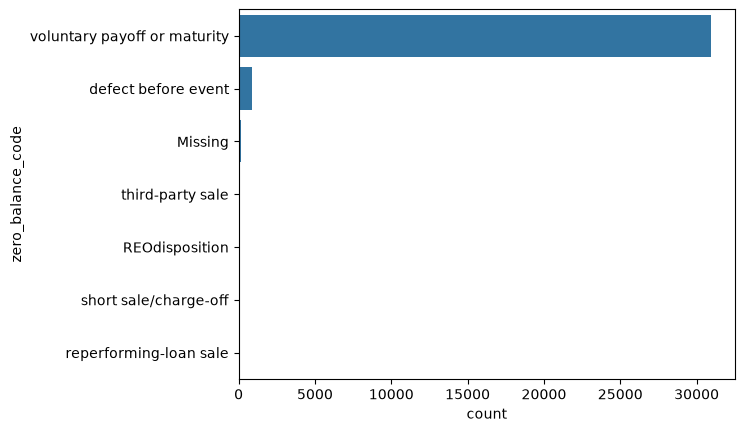

In [17]:
#sns.barplot(zero_balance_code_distribution.drop(index=["Missing"]),orient="h")
sns.barplot(zero_balance_code_distribution,orient="h")

In [18]:
default_events = [
    "third-party sale",
    "REOdisposition",
    "short sale/charge-off"
]
non_default_events = [
    "voluntary payoff or maturity",
    "reperforming-loan sale"
]
uncertain_events = [
    "defect before event",  
    "Missing"               
]

defaults = zero_balance_code_distribution.loc[default_events].sum()
non_default = zero_balance_code_distribution.loc[non_default_events].sum()
uncertain = zero_balance_code_distribution.loc[uncertain_events].sum()
total = zero_balance_code_df.shape[0]

print(f"Non-default loans are : {non_default} and are the {round(non_default/total,3)} % of non cosidered loans")
print(f"Uncertain loans are : {uncertain} and are the {round(uncertain/total,3)} % of non cosidered loans")
print(f"\n\nDefault loans are : {defaults} and are the {round(defaults/total,3)} % of non cosidered loans")
print(f"This loans are {round(defaults/n_loans,4)} % of the total loans")
print("The number of not considered default is negligible , we will continue with our data ")


Non-default loans are : 30943 and are the 0.967 % of non cosidered loans
Uncertain loans are : 1039 and are the 0.032 % of non cosidered loans


Default loans are : 25 and are the 0.001 % of non cosidered loans
This loans are 0.0001 % of the total loans
The number of not considered default is negligible , we will continue with our data 


In [19]:
print("There is no significant differenc in this features considered")
origin_2024_Q1_eda.groupby("has_month_20_target")[["classic_fico","original_dti","original_ltv","original_interest_rate"]].agg(["mean","std"]).T


There is no significant differenc in this features considered


has_month_20_target                   0           1
classic_fico           mean  758.880839  753.069322
                       std   191.824179  146.906238
original_dti           mean   37.871309   37.990301
                       std     9.576747   10.046357
original_ltv           mean   70.839223   75.947962
                       std    20.675568   19.183611
original_interest_rate mean    6.920193    6.703909
                       std     0.544620    0.533939

## Numerical and categorical risk

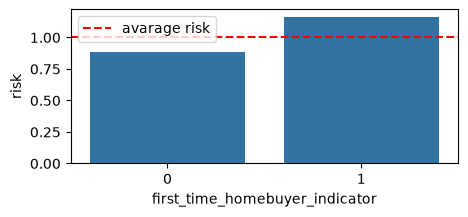

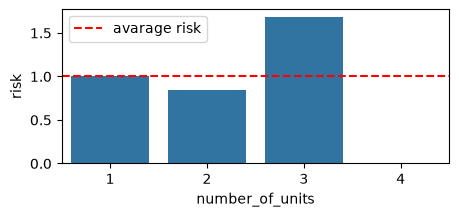

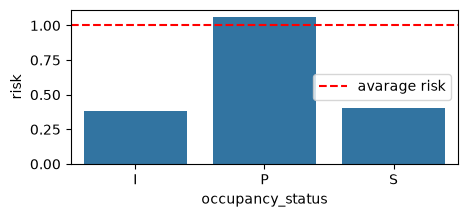

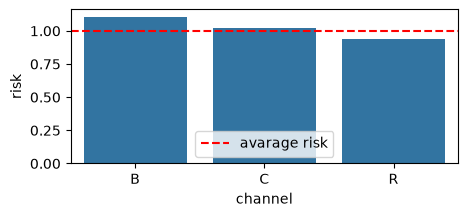

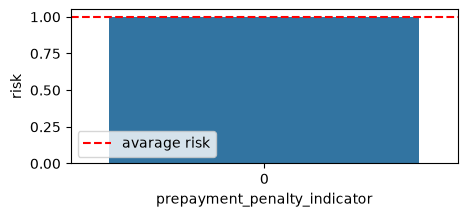

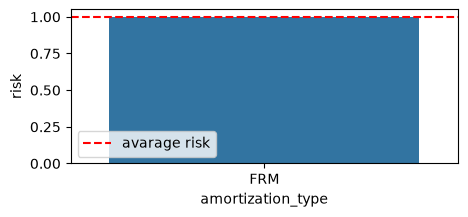

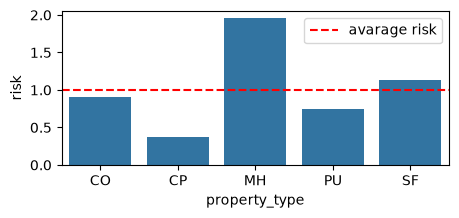

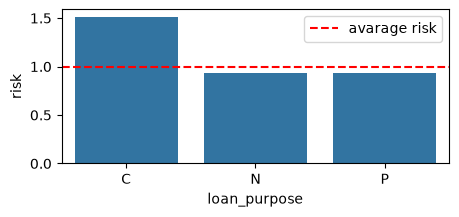

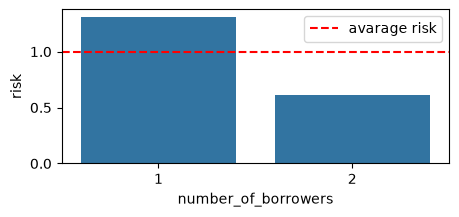

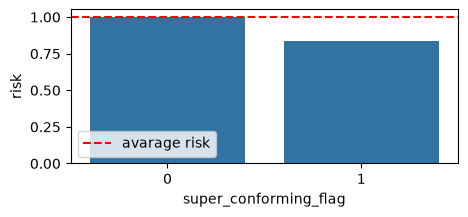

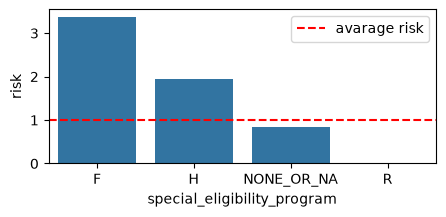

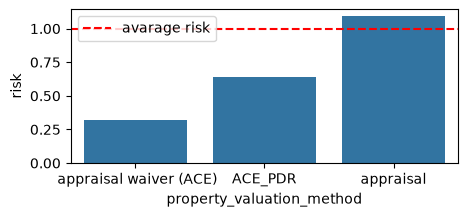

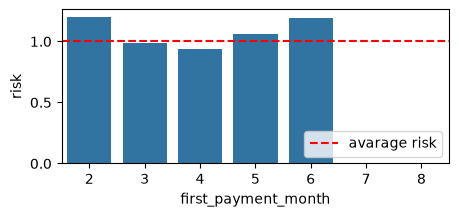

In [20]:
categorical_columns_eda = [col for col in categorical_columns if model_df_eda[col].nunique() <= 10]
for col in categorical_columns_eda:
    df=model_df.groupby(col).target_90plus.agg(["mean","count"])
    df["risk"]=df["mean"]/global_defective

    fig ,ax = plt.subplots(figsize=(5,2))
    sns.barplot(data = df , x=df.index,y=df.risk,ax=ax)
    ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
    ax.legend()


    


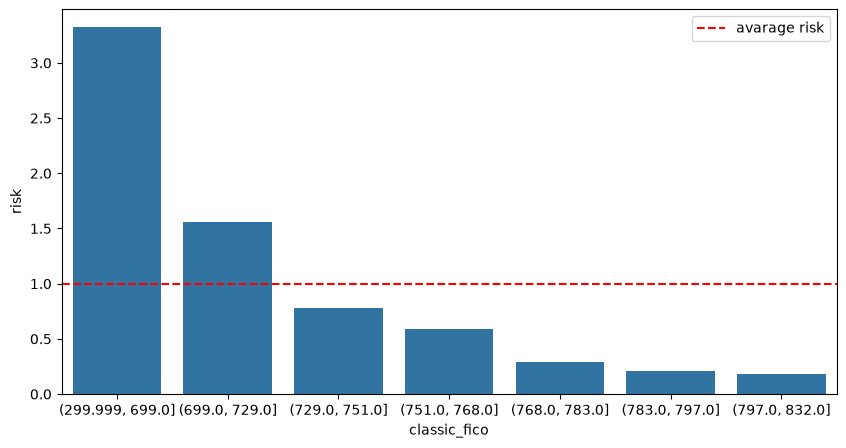

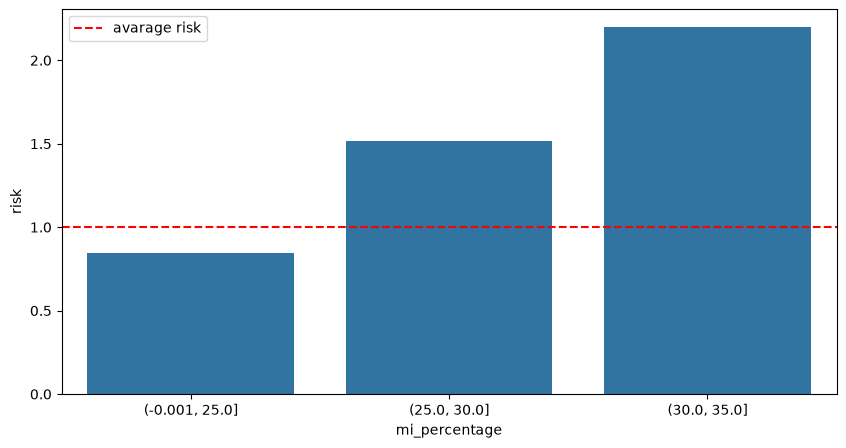

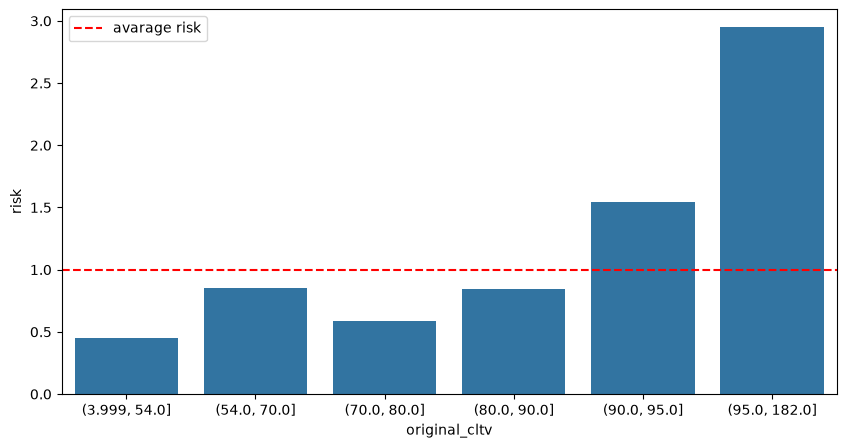

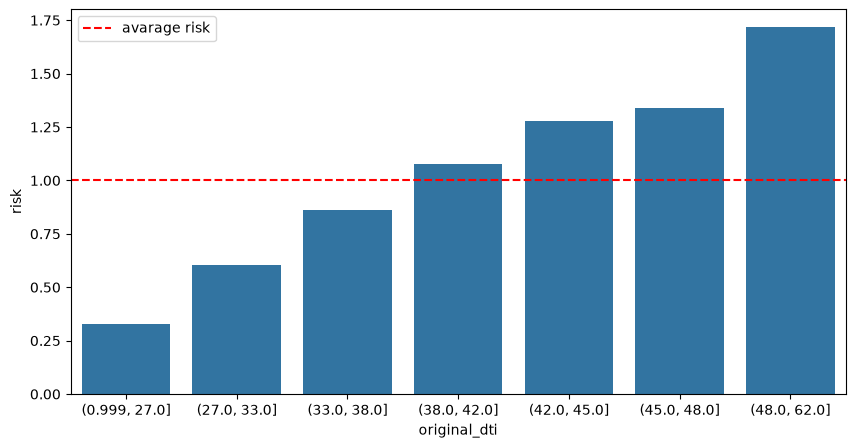

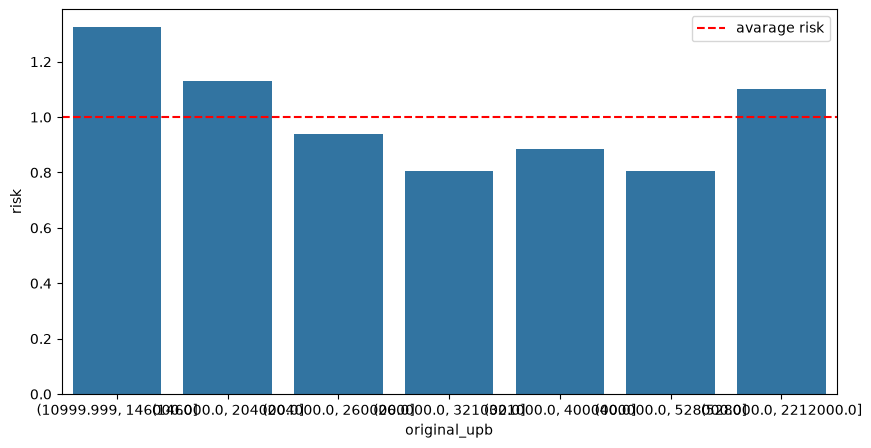

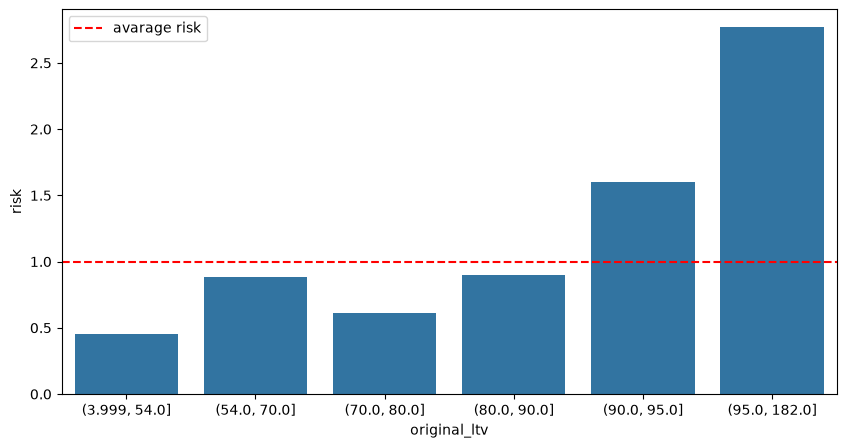

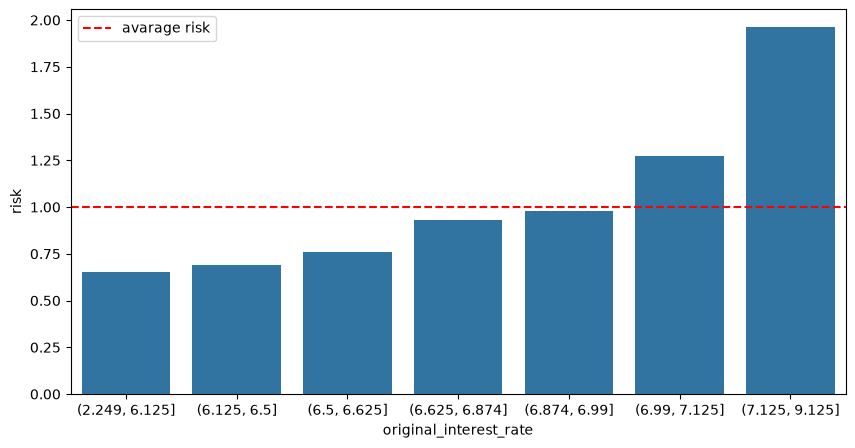

In [21]:

for col in numerical_columns:
    df = model_df[[col,"target_90plus"]].dropna().copy()
    df["bin"]= pd.qcut(
        model_df[col],
        q=7,
        duplicates="drop"
    )
    del df[col]
    df = df.groupby("bin").mean()
    df["risk"]=df/global_defective

    fig ,ax = plt.subplots(figsize=(10,5))
    sns.barplot(data=df,x=df.index , y=df.risk,ax=ax)
    ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
    ax.legend()
    plt.xlabel(col)
    

## Missing value risk

this feature sees to have a slightly higher risk compard to default , we will consider that


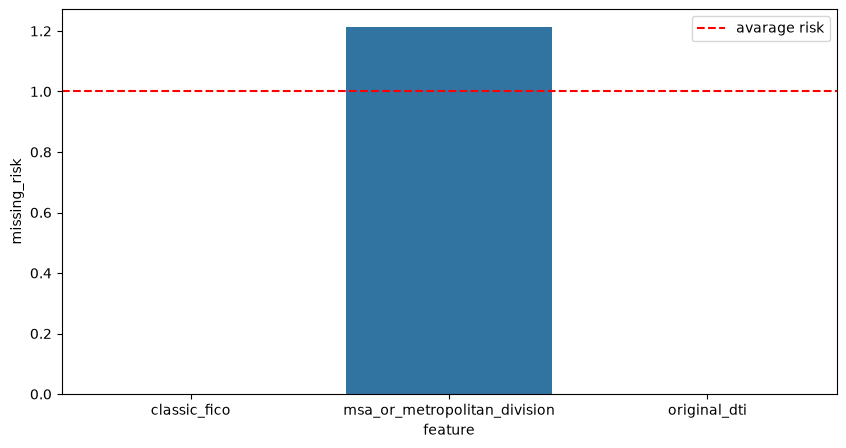

In [22]:
missing_risk = []
for col in columns:
    score = model_df_eda.iloc[model_df_eda[col].isnull(),:].target_90plus.mean()
    if not pd.isna(score):
        missing_risk.append((col,score/global_defective))

missing_risk_df = pd.DataFrame(missing_risk , columns=["feature","missing_risk"])

fig , ax = plt.subplots(figsize=(10,5))
sns.barplot(data=missing_risk_df,x=missing_risk_df["feature"],y=missing_risk_df["missing_risk"],ax=ax)
ax.axhline(y=1,color="red",linestyle="--",label="avarage risk")
ax.legend()
print("this feature sees to have a slightly higher risk compard to default , we will consider that")


## Mutual info and correlation analisys

<Axes: >

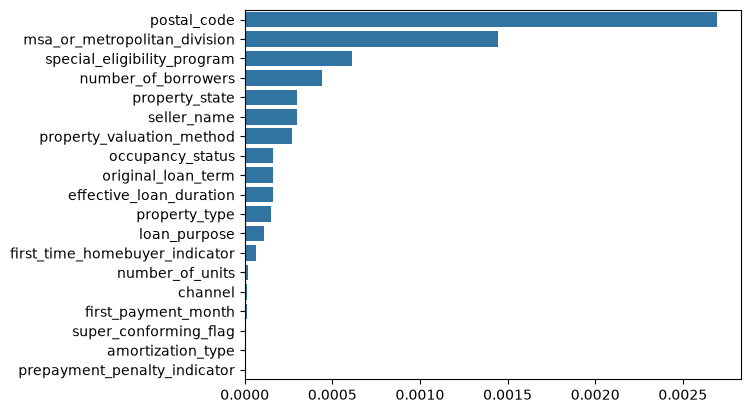

In [23]:
model_df_eda["msa_or_metropolitan_division"] = model_df_eda["msa_or_metropolitan_division"].fillna("NOT available")

def get_mi(column):
    return mutual_info_score(column,model_df_eda.target_90plus)

mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)

sns.barplot(mi,orient="h")

<Axes: >

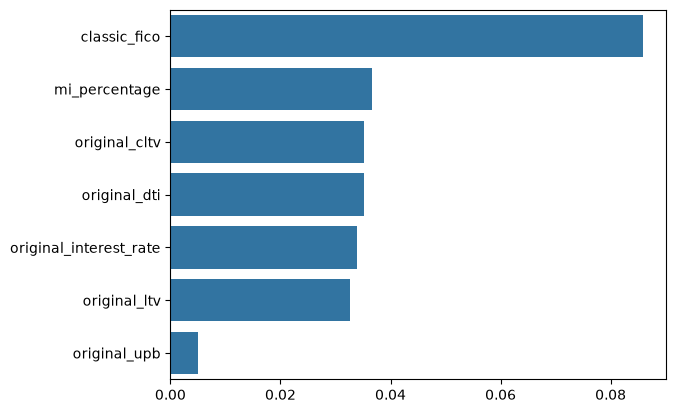

In [24]:
model_df_eda = model_df_eda.fillna(0)

correlation = model_df_eda[numerical_columns].corrwith(model_df_eda.target_90plus).abs().sort_values(ascending=False)

sns.barplot(correlation,orient="h")

## trying to create new features  

<Axes: >

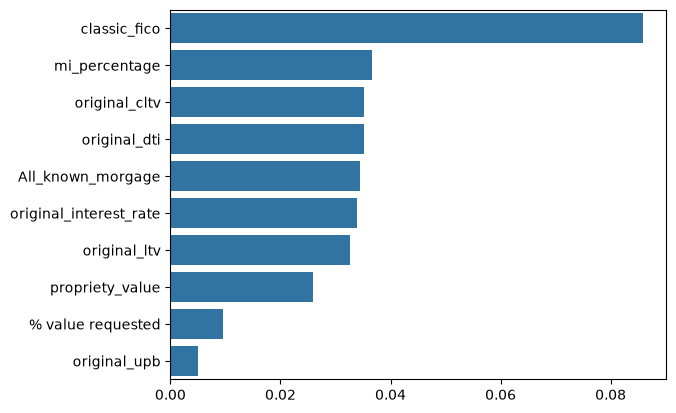

In [25]:
model_df_eda_try = model_df_eda.copy()
'''
def calc(P,r,n):
    numerator = ((1+r)**n)*r
    denominator = ((1+r)**n)-1
    return (numerator/denominator)*P*n

model_df_eda_try["total_amount"]=calc(model_df_eda_try["original_upb"],model_df_eda_try["original_interest_rate"],model_df_eda_try["effective_loan_duration"].astype("float64")).astype("float64")
'''
model_df_eda_try["propriety_value"]=model_df_eda_try["original_ltv"]/model_df_eda_try["original_upb"]
model_df_eda_try["All_known_morgage"]=model_df_eda_try["original_cltv"]*model_df_eda_try["propriety_value"]
model_df_eda_try["% value requested"]=model_df_eda_try["original_upb"]/model_df_eda_try["propriety_value"]

new_columns=["propriety_value","All_known_morgage","% value requested"]
correlation = model_df_eda_try[numerical_columns+new_columns].corrwith(model_df_eda_try.target_90plus).abs().sort_values(ascending=False)

sns.barplot(correlation,orient="h")

In [26]:
model_df_eda_try[numerical_columns].dtypes

classic_fico              float64
mi_percentage             float64
original_cltv             float64
original_dti              float64
original_upb              float64
original_ltv              float64
original_interest_rate    float64
dtype: object

## Correlation between features

<Axes: >

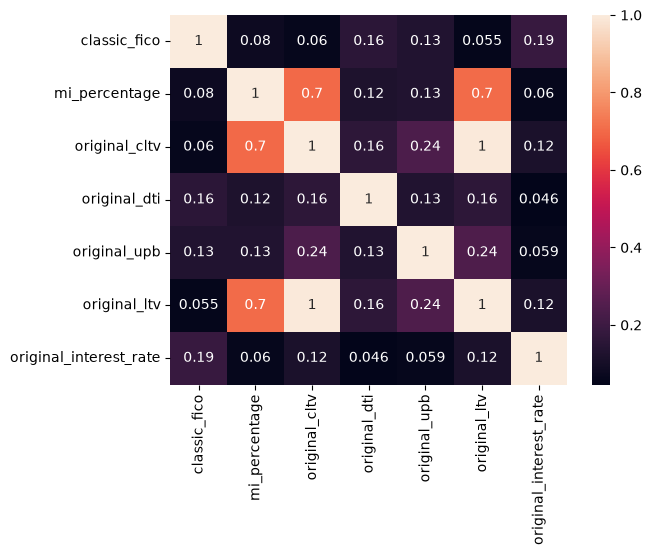

In [52]:
df_corr={}
for col in numerical_columns:
    correlation = model_df_eda[numerical_columns].corrwith(model_df_eda[col]).abs()
    df_corr[col]=correlation
df_corr = pd.DataFrame(df_corr)
sns.heatmap(data = df_corr ,annot=True)

In [ ]:


'''
df_mi={}
for col in categorical_columns:
    def get_mi(column):
        return mutual_info_score(column,model_df_eda[col])
    mi = model_df_eda[categorical_columns].apply(get_mi).sort_values(ascending=False)
    df_mi[col]=mi
df_mi = pd.DataFrame(df_mi)
df_mi
'''

,first_time_homebuyer_indicator,msa_or_metropolitan_division,number_of_units,occupancy_status,channel,prepayment_penalty_indicator,amortization_type,property_state,property_type,postal_code,loan_purpose,original_loan_term,number_of_borrowers,seller_name,super_conforming_flag,special_eligibility_program,property_valuation_method,first_payment_month,effective_loan_duration
amortization_type,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
channel,0.001785,0.040692,0.000312,0.000754,1.020923,0.0,0.0,0.030407,0.004414,0.050378,0.010899,0.003063,0.000261,0.455348,0.000634,0.025656,0.003363,0.001158,0.003063
effective_loan_duration,0.007098,0.010935,0.000126,0.000331,0.003063,0.0,0.0,0.003933,0.002354,0.017597,0.021457,0.281979,0.000268,0.011461,0.000343,0.005989,0.002664,0.000688,0.281979
first_payment_month,0.000562,0.007424,0.000140,0.000232,0.001158,0.0,0.0,0.002995,0.000601,0.012230,0.002309,0.000688,0.000129,0.006120,0.000043,0.000467,0.000564,1.123104,0.000688
first_time_homebuyer_indicator,0.678797,0.014954,0.001312,0.049867,0.001785,0.0,0.0,0.009183,0.004115,0.019715,0.103120,0.007098,0.000004,0.004919,0.000082,0.034315,0.002312,0.000562,0.007098
loan_purpose,0.103120,0.012179,0.000982,0.002980,0.010899,0.0,0.0,0.004862,0.013239,0.016683,0.560170,0.021457,0.000797,0.026088,0.000535,0.017836,0.007776,0.002309,0.021457
msa_or_metropolitan_division,0.014954,5.021205,0.015713,0.014568,0.040692,0.0,0.0,3.028759,0.182378,4.658776,0.012179,0.010935,0.008027,0.156727,0.021363,0.041474,0.009838,0.007424,0.010935
number_of_borrowers,0.000004,0.008027,0.000318,0.000869,0.000261,0.0,0.0,0.004778,0.004045,0.011723,0.000797,0.000268,0.687391,0.002099,0.000715,0.017358,0.000070,0.000129,0.000268
number_of_units,0.001312,0.015713,0.109666,0.013636,0.000312,0.0,0.0,0.009927,0.010298,0.022469,0.000982,0.000126,0.000318,0.000959,0.000006,0.000160,0.002653,0.000140,0.000126
occupancy_status,0.049867,0.014568,0.013636,0.340043,0.000754,0.0,0.0,0.004589,0.003353,0.021643,0.002980,0.000331,0.000869,0.005122,0.000376,0.011503,0.010272,0.000232,0.000331


In [61]:
categorical_interesting=["msa_or_metropolitan_division","property_state","postal_code"]
df_mi={}
for col in categorical_interesting:
    def get_mi(column):
        return mutual_info_score(column,model_df_eda[col])
    mi = model_df_eda[categorical_interesting].apply(get_mi).sort_values(ascending=False)
    df_mi[col]=mi
df_mi = pd.DataFrame(df_mi)
df_mi

,msa_or_metropolitan_division,property_state,postal_code
msa_or_metropolitan_division,5.021205,3.028759,4.658776
postal_code,4.658776,3.467003,6.174304
property_state,3.028759,3.467021,3.467003


<Axes: >

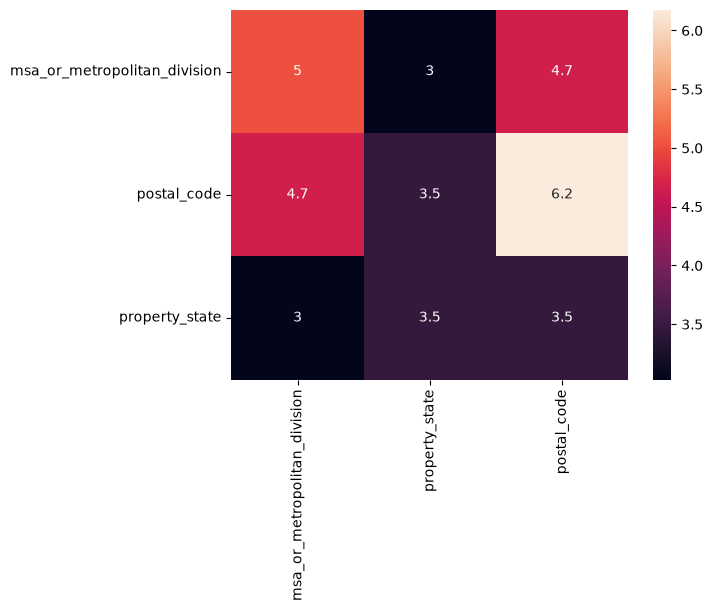

In [63]:
#plt.figure(figsize=(19,19))
sns.heatmap(data=df_mi,annot=True)

# Validation Framework setup

In [ ]:
X_full_train , X_test = train_test_split(model_df,random_state=1,test_size=0.2)
X_train , X_val = train_test_split(X_full_train,random_state=1,test_size=0.25)


X_train=X_train.reset_index(drop=True)
X_test=X_test.reset_index(drop=True)
X_val=X_val.reset_index(drop=True)
X_full_train=X_full_train.reset_index(drop=True)

y_train = X_train["target_90plus"].values
y_test = X_test["target_90plus"].values
y_val = X_val["target_90plus"].values
y_full_train = X_full_train["target_90plus"].values

# carefull the target is still in the data sets